In [1]:
%pip install sentence_transformers

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('tmdb_movies_target_count.csv', skiprows=[1])
df.head()

,tmdb_id,title,release_date,year,original_language,runtime,genres,budget,revenue,popularity,vote_average,vote_count,director,top_actors,overview,success_label,success_reason
0,338969,The Toxic Avenger Unrated,2025-08-28,2025.0,en,102,"Action, Comedy, Science Fiction",0,3328938,140.8880,6.345,145,Macon Blair,"Peter Dinklage, Jacob Tremblay, Taylour Paige","When a downtrodden janitor, Winston Gooze, is ...",Average/Positive,Decent user score (no financials)
1,1327769,27 Nights,2025-09-19,2025.0,es,108,Comedy,0,0,126.7053,6.600,7,Daniel Hendler,"Marilú Marini, Daniel Hendler, Humberto Tortonese",When a woman is admitted by her daughters to a...,Average/Positive,Decent user score (no financials)
2,803796,KPop Demon Hunters,2025-06-20,2025.0,en,96,"Fantasy, Music, Comedy, Animation",100000000,19200000,135.6947,8.248,1728,Chris Appelhans,"Arden Cho, May Hong, Ji-young Yoo","When K-pop superstars Rumi, Mira and Zoey aren...",Moderate,At least broke even or decent ratings
3,1267905,The Roses,2025-08-27,2025.0,en,105,"Comedy, Drama, Romance",30600000,49589664,97.3762,7.031,229,Jay Roach,"Olivia Colman, Benedict Cumberbatch, Kate McKi...",Life seems easy for picture-perfect couple Ivy...,Moderate,At least broke even or decent ratings
4,1277988,Caramelo,2025-10-08,2025.0,pt,101,"Comedy, Drama",0,0,71.6315,7.775,120,Diego Freitas,"Rafael Vitti, Amendoim, Arianne Botelho","After a life-changing diagnosis, a promising c...",Average/Positive,Decent user score (no financials)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tmdb_id            1015 non-null   int64  
 1   title              1015 non-null   object 
 2   release_date       1014 non-null   object 
 3   year               1014 non-null   float64
 4   original_language  1015 non-null   object 
 5   runtime            1015 non-null   int64  
 6   genres             1015 non-null   object 
 7   budget             1015 non-null   int64  
 8   revenue            1015 non-null   int64  
 9   popularity         1015 non-null   float64
 10  vote_average       1015 non-null   float64
 11  vote_count         1015 non-null   int64  
 12  director           1015 non-null   object 
 13  top_actors         1015 non-null   object 
 14  overview           1013 non-null   object 
 15  success_label      1015 non-null   object 
 16  success_reason     1015 

In [10]:
df.describe()

,tmdb_id,year,runtime,budget,revenue,popularity,vote_average,vote_count
count,1.015000e+03,1014.000000,1015.000000,1.015000e+03,1.015000e+03,1015.000000,1015.000000,1015.000000
mean,3.835880e+05,2009.789941,100.389163,3.811788e+07,1.383859e+08,10.144546,6.519136,3261.005911
std,4.575110e+05,14.463156,22.385789,4.770608e+07,2.125161e+08,9.868764,1.169387,4105.256666
min,1.300000e+01,1931.000000,0.000000,0.000000e+00,0.000000e+00,4.270800,0.000000,0.000000
25%,1.092950e+04,2002.000000,91.000000,0.000000e+00,0.000000e+00,6.458900,6.117500,299.500000
50%,1.273800e+05,2013.000000,100.000000,2.000000e+07,5.166377e+07,7.749800,6.671000,1849.000000
75%,6.865955e+05,2022.000000,110.000000,6.000000e+07,1.927590e+08,10.434050,7.170500,4634.000000
max,1.565344e+06,2027.000000,212.000000,2.500000e+08,1.698864e+09,140.888000,10.000000,32007.000000


In [11]:
df.isnull().sum()

,0
tmdb_id,0
title,0
release_date,1
year,1
original_language,0
runtime,0
genres,0
budget,0
revenue,0
popularity,0


In [17]:
df['release_date'].fillna(df['release_date'].mode()[0], inplace=True)
df['year'].fillna(df['year'].median(), inplace=True)
df['overview'].fillna('No overview available', inplace=True)

/tmp/ipython-input-2696559812.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['release_date'].fillna(df['release_date'].mode()[0], inplace=True)
/tmp/ipython-input-2696559812.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [18]:
df.isnull().sum()

,0
tmdb_id,0
title,0
release_date,0
year,0
original_language,0
runtime,0
genres,0
budget,0
revenue,0
popularity,0


# DATE FEATURES (from release_date)



In [19]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_month'] = df['release_date'].dt.month
df['release_day_of_week'] = df['release_date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['release_quarter'] = df['release_date'].dt.quarter

In [20]:
df['is_summer_release'] = df['release_month'].isin([5, 6, 7, 8]).astype(int)

# Holiday release? (November-December)
df['is_holiday_release'] = df['release_month'].isin([11, 12]).astype(int)

#  GENRES (Multi-hot encoding)


In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

# Multi-label for genres
mlb = MultiLabelBinarizer()
df['genres'] = df['genres'].str.split(', ')
genre_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_)
df = pd.concat([df, genre_encoded], axis=1)
df.drop('genres', axis=1, inplace=True)

# **Actors (Multi-hot + Target Encoding)**

In [24]:
def parse_list(text):
    if pd.isna(text):
        return []
    return [item.strip() for item in str(text).split(',')]



# 1️⃣ Parse the actor list
df['actors_list'] = df['top_actors'].apply(parse_list)

# 2️⃣ Find top 100 most frequent actors (vectorized)
actor_counts = pd.Series([a for actors in df['actors_list'] for a in actors]).value_counts()
top_actors = actor_counts.head(100).index.tolist()

# 3️⃣ Multi-hot encoding for top actors (vectorized with sklearn)
mlb = MultiLabelBinarizer(classes=top_actors)
actor_encoded = pd.DataFrame(mlb.fit_transform(df['actors_list']), columns=[f'actor_{a}' for a in mlb.classes_], index=df.index)

# Concatenate back to df
df = pd.concat([df, actor_encoded], axis=1)

# 4️⃣ Target encoding with CV (vectorized)
def target_encode_cv_fast(df, list_col, target_col='vote_average', n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mean_encoded = np.zeros(len(df))
    max_encoded = np.zeros(len(df))
    min_encoded = np.zeros(len(df))

    for train_idx, val_idx in kf.split(df):
        train_df, val_df = df.iloc[train_idx], df.iloc[val_idx]

        # explode to (movie, actor) pairs
        exploded = train_df[[list_col, target_col]].explode(list_col).dropna()
        # average rating per actor
        actor_mean = exploded.groupby(list_col)[target_col].mean()
        global_mean = train_df[target_col].mean()

        # now apply to validation fold
        val_means = []
        val_maxs = []
        val_mins = []
        for actors in val_df[list_col]:
            if not actors:  # empty list
                vals = [global_mean]
            else:
                vals = [actor_mean.get(a, global_mean) for a in actors]
            val_means.append(np.mean(vals))
            val_maxs.append(np.max(vals))
            val_mins.append(np.min(vals))

        mean_encoded[val_idx] = val_means
        max_encoded[val_idx] = val_maxs
        min_encoded[val_idx] = val_mins

    return mean_encoded, max_encoded, min_encoded

df['actors_rating_mean'], df['actors_rating_max'], df['actors_rating_min'] = target_encode_cv_fast(
    df, 'actors_list', 'vote_average'
)

# 5️⃣ Count features
df['num_actors'] = df['actors_list'].apply(len)
df['num_top_actors'] = df['actors_list'].apply(lambda x: sum(1 for a in x if a in top_actors))


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Aamir Khan', 'Aaron Eckhart', 'Aaron Harris', 'Aaron Taylor-Johnson', 'Aavi Haas', 'Abbey Hoes', 'Adam Brody', 'Adam Demos', 'Adam Driver', 'Adam Malamut', 'Adam Scott', 'Addison Riecke', 'Adria Arjona', 'Adrian Grenier', 'Adrian Martinez', 'Adrien Brody', 'Adèle Exarchopoulos', 'Agnès Jaoui', 'Ahn So-yi', 'Aidan Delbis', 'Aidan Gillen', 'Aiko Yoshimoto', 'Aimee Carrero', 'Aimee Stolte', 'Akanksha Sharma', 'Akemi Okamura', 'Akiho Yoshizawa', 'Akira Sekine', 'Aksel Hennie', 'Alain Chabat', 'Alan Arkin', 'Alan Dale', 'Alan Ford', 'Alan Rickman', 'Alan Ritchson', 'Alan Ruck', 'Albert Brooks', 'Albert Tsai', 'Alberto Sordi', 'Aldis Hodge', 'Aldo Baglio', 'Aldo Sambrell', 'Alec Baldwin', 'Alessandro Momo', 'Alex Ashbaugh', 'Alex D. Linz', 'Alex Pettyfer', 'Alexa PenaVega', 'Alexia Chardard', 'Alf Goddard', 'Alice Eve', 'Alicia Silverstone', 'Alicia Vikander', 'Alisha Weir', 'Alison 

# DIRECTORS (Multi-hot + Target Encoding)

In [34]:
df['director_list'] = df['director'].apply(parse_list)

director_counts = pd.Series([a for directors in df['director_list'] for a in directors]).value_counts()
top_directors = director_counts.head(50).index.tolist()

mlb = MultiLabelBinarizer(classes=top_director)
director_encoded = pd.DataFrame(mlb.fit_transform(df['director_list']), columns=[f'director_{a}' for a in mlb.classes_], index=df.index)

# Concatenate back to df
df = pd.concat([df, director_encoded], axis=1)


df['director_rating_mean'], df['director_rating_max'], df['director_rating_min'] = \
    target_encode_cv_fast(df, 'director_list', 'vote_average')

df['has_top_director'] = df['director_list'].apply(lambda x: 1 if any(d in top_directors for d in x) else 0)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Aaron Horvath', 'Aaron Nee', 'Abdellatif Kechiche', 'Adam Deyoe', 'Adam Elliot', 'Adam Shankman', 'Adil El Arbi', 'Aditya Chopra', 'Aditya Sarpotdar', 'Agustín Rolandelli', 'Akira Fukamachi', 'Akiva Schaffer', 'Alain Chabat', 'Alberto Belli', 'Alberto Lattuada', 'Alejandro González Iñárritu', 'Alex Pillai', 'Alex Scharfman', 'Alex Winter', 'Alexander Payne', 'Alexandre Aja', 'Alfonso Albacete', 'Alfonso Cuarón', 'Allan Ungar', 'Amen Au Cheuk-Man', 'Amy Heckerling', 'Andrew Adamson', 'Andrew DeYoung', 'Andrew Stanton', 'Andrew Waller', 'Andy Fickman', 'Andy Tennant', 'Angela Robinson', 'Anne Fletcher', 'Anush Mohan', 'Ari Aster', 'Ari Sandel', 'Ariel Schulman', 'Arthur Fontes', 'Arturo Perez Jr.', 'Ash Brannon', 'Audie Harrison', 'Audrey Wells', 'Aurelio Grimaldi', 'Austin Bragg', 'Avid Liongoren', 'Azazel Jacobs', 'Aziz Ansari', 'B. Harrison Smith', 'Baltasar Kormákur', 'Ben St

# **LANGUAGE (One-hot or group rare languages)**

In [36]:
lang_count = df['original_language'].value_counts()

top_lang_list = set(lang_count[lang_count >= 10].index)

df['language'] = df['original_language'].apply(lambda x: x if x in top_lang_list else "Other")

lang_dummies = pd.get_dummies(df['language'], prefix="lang")
df = pd.concat([df, lang_dummies], axis=1)

# **BUDGET & REVENUE FEATURES**

In [37]:
df['budget_log'] = np.log1p(df['budget'])  # log1p = log(1 + x), handles zeros
df['revenue_log'] = np.log1p(df['revenue'])

# Budget categories
df['has_budget'] = (df['budget'] > 0).astype(int)
df['budget_category'] = pd.cut(df['budget'],
                                bins=[0, 1e6, 10e6, 50e6, 100e6, np.inf],
                                labels=['Zero', 'Low', 'Medium', 'High', 'Blockbuster'])
budget_cat_dummies = pd.get_dummies(df['budget_category'], prefix='budget_cat')
df = pd.concat([df, budget_cat_dummies], axis=1)

# Profit (if revenue exists)
df['profit'] = df['revenue'] - df['budget']
df['profit_log'] = np.log1p(df['profit'].clip(lower=0))  # Only positive profits

# ROI (Return on Investment)
df['roi'] = df.apply(lambda x: (x['revenue'] - x['budget']) / x['budget']
                     if x['budget'] > 0 else 0, axis=1)


# **RUNTIME FEATURES**

In [38]:
df['runtime_category'] = pd.cut(df['runtime'],
                                 bins=[0, 90, 120, 150, np.inf],
                                 labels=['Short', 'Medium', 'Long', 'VeryLong'])
runtime_dummies = pd.get_dummies(df['runtime_category'], prefix='runtime')
df = pd.concat([df, runtime_dummies], axis=1)

# Is it a typical movie length? (90-130 mins)
df['is_standard_length'] = df['runtime'].between(90, 130).astype(int)


# **POPULARITY & VOTE COUNT**

In [39]:
df['popularity_log'] = np.log1p(df['popularity'])
df['vote_count_log'] = np.log1p(df['vote_count'])

# Popularity bins
df['popularity_category'] = pd.cut(df['popularity'],
                                    bins=[0, 10, 50, 100, np.inf],
                                    labels=['Low', 'Medium', 'High', 'VeryHigh'])
pop_dummies = pd.get_dummies(df['popularity_category'], prefix='pop')
df = pd.concat([df, pop_dummies], axis=1)

# **TEXT FEATURES (from overview)**

In [41]:
df['overview_length'] = df['overview'].apply(lambda x: len(str(x)))
df['overview_word_count'] = df['overview'].apply(lambda x: len(str(x).split()))

tfidf = TfidfVectorizer(max_features=50, stop_words='english')
overview_features = tfidf.fit_transform(df['overview'])
overview_df = pd.DataFrame(overview_features.toarray(),
                           columns=[f'overview_tfidf_{i}' for i in range(50)])
df = pd.concat([df, overview_df], axis=1)

# **INTERACTION FEATURES**

In [42]:
# Budget per minute
df['budget_per_minute'] = df.apply(lambda x: x['budget'] / x['runtime']
                                   if x['runtime'] > 0 else 0, axis=1)

# Popularity per vote
df['popularity_per_vote'] = df.apply(lambda x: x['popularity'] / x['vote_count']
                                     if x['vote_count'] > 0 else 0, axis=1)

# **Dropping Columns**

In [44]:
drop_cols = [
    'tmdb_id', 'title', 'release_date', 'director', 'top_actors',
    'overview', 'success_label', 'success_reason', 'original_language',
    'genres_list', 'actors_list', 'director_list', 'language',
    'budget_category', 'runtime_category', 'popularity_category'
]

df_processed = df.drop(columns=drop_cols, errors='ignore')

In [46]:
df_processed.head()

,year,runtime,budget,revenue,popularity,vote_average,vote_count,release_month,release_day_of_week,release_quarter,...,overview_tfidf_42,overview_tfidf_43,overview_tfidf_44,overview_tfidf_45,overview_tfidf_46,overview_tfidf_47,overview_tfidf_48,overview_tfidf_49,budget_per_minute,popularity_per_vote
0,2025.0,102,0,3328938,140.8880,6.345,145,8,3,3,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.971641
1,2025.0,108,0,0,126.7053,6.600,7,9,4,3,...,0.0,0.0,0.0,0.820497,0.0,0.0,0.0,0.0,0.000000e+00,18.100757
2,2025.0,96,100000000,19200000,135.6947,8.248,1728,6,4,2,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.041667e+06,0.078527
3,2025.0,105,30600000,49589664,97.3762,7.031,229,8,2,3,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,2.914286e+05,0.425224
4,2025.0,101,0,0,71.6315,7.775,120,10,2,4,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.596929


# **Preparing X and y**

In [47]:
y = df_processed['vote_average']

X = df_processed.drop(columns=['vote_average', 'vote_count'])

# Fill any remaining NaNs with 0 (shouldn't be many)
X = X.fillna(0)

# Check for infinite values
X = X.replace([np.inf, -np.inf], 0)

# **Train-Test Split**

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Total features: {X.shape[1]}")
print(f"\nFeature columns: {X.columns.tolist()}")

Training set: (812, 371)
Test set: (203, 371)
Total features: 371

Feature columns: ['year', 'runtime', 'budget', 'revenue', 'popularity', 'release_month', 'release_day_of_week', 'release_quarter', 'is_summer_release', 'is_holiday_release', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western', 'actor_Adam Sandler', 'actor_Jack Black', 'actor_Ben Stiller', 'actor_Cameron Diaz', 'actor_Emma Stone', 'actor_Eddie Murphy', 'actor_Ryan Reynolds', 'actor_Tom Hanks', 'actor_Anne Hathaway', 'actor_Steve Carell', 'actor_Jim Carrey', 'actor_Dwayne Johnson', 'actor_Jackie Chan', 'actor_Martin Lawrence', 'actor_Will Ferrell', 'actor_Will Smith', 'actor_Owen Wilson', 'actor_Jonah Hill', 'actor_Mike Myers', 'actor_Jennifer Aniston', 'actor_Kevin Hart', 'actor_Anna Kendrick', 'actor_Anna Faris', 'actor_Kristen Wiig', 'actor_Ryan Gosling', 'actor_Mark Wahlberg'

In [59]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Convert to float32 (more efficient for XGBoost)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# **Training**

# **Hyperparameter Tuning**

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error
import time

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

print("RANDOM FOREST - HYPERPARAMETER TUNING")

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring=mae_scorer,
    verbose=2,
    n_jobs=-1
)


start_time = time.time()
rf_grid.fit(X_train_np, y_train_np)
rf_time = time.time() - start_time

print(f"\nTuning complete in {rf_time/60:.2f} minutes")
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV MAE: {-rf_grid.best_score_:.4f}")

# Store best model
rf_best = rf_grid.best_estimator_

RANDOM FOREST - HYPERPARAMETER TUNING
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Tuning complete in 4.34 minutes
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MAE: 0.5898


In [68]:
from sklearn.model_selection import RandomizedSearchCV

print("="*70)
print("XGBOOST - HYPERPARAMETER TUNING (RANDOMIZED)")
print("="*70)

# Same parameter grid
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [3, 4, 5],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 1.5, 2.0]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist')

# RandomizedSearchCV - only tests 50 random combinations
xgb_grid = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=50,  # Test only 50 combinations instead of 3888
    cv=5,
    scoring=mae_scorer,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
xgb_grid.fit(X_train_np, y_train_np)
xgb_time = time.time() - start_time

print(f"\nTuning complete in {xgb_time/60:.2f} minutes")
print(f"Best parameters: {xgb_grid.best_params_}")
print(f"Best CV MAE: {-xgb_grid.best_score_:.4f}")

xgb_best = xgb_grid.best_estimator_

XGBOOST - HYPERPARAMETER TUNING (RANDOMIZED)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning complete in 1.59 minutes
Best parameters: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 1.0, 'n_estimators': 200, 'min_child_weight': 4, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV MAE: 0.4532


# **Train and Evaluate Random Forest**

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("RANDOM FOREST - EVALUATION")

# Predictions
rf_train_pred = rf_best.predict(X_train_np)
rf_test_pred = rf_best.predict(X_test_np)

# Training metrics
rf_train_mae = mean_absolute_error(y_train_np, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train_np, rf_train_pred))
rf_train_r2 = r2_score(y_train_np, rf_train_pred)

# Test metrics
rf_test_mae = mean_absolute_error(y_test_np, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test_np, rf_test_pred))
rf_test_r2 = r2_score(y_test_np, rf_test_pred)

# Display results
print("\nTraining Set:")
print(f"  MAE:  {rf_train_mae:.4f}")
print(f"  RMSE: {rf_train_rmse:.4f}")
print(f"  R2:   {rf_train_r2:.4f}")

print("\nTest Set:")
print(f"  MAE:  {rf_test_mae:.4f}")
print(f"  RMSE: {rf_test_rmse:.4f}")
print(f"  R2:   {rf_test_r2:.4f}")

print(f"\nOverfitting Gap: {abs(rf_train_mae - rf_test_mae):.4f}")

RANDOM FOREST - EVALUATION

Training Set:
  MAE:  0.4466
  RMSE: 0.6409
  R2:   0.7255

Test Set:
  MAE:  0.5387
  RMSE: 0.7174
  R2:   0.3827

Overfitting Gap: 0.0921


# **Train and Evaluate XGBoost**

In [70]:
print("XGBOOST - EVALUATION")

# Predictions
xgb_train_pred = xgb_best.predict(X_train_np)
xgb_test_pred = xgb_best.predict(X_test_np)

# Training metrics
xgb_train_mae = mean_absolute_error(y_train_np, xgb_train_pred)
xgb_train_rmse = np.sqrt(mean_squared_error(y_train_np, xgb_train_pred))
xgb_train_r2 = r2_score(y_train_np, xgb_train_pred)

# Test metrics
xgb_test_mae = mean_absolute_error(y_test_np, xgb_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test_np, xgb_test_pred))
xgb_test_r2 = r2_score(y_test_np, xgb_test_pred)

# Display results
print("\nTraining Set:")
print(f"  MAE:  {xgb_train_mae:.4f}")
print(f"  RMSE: {xgb_train_rmse:.4f}")
print(f"  R2:   {xgb_train_r2:.4f}")

print("\nTest Set:")
print(f"  MAE:  {xgb_test_mae:.4f}")
print(f"  RMSE: {xgb_test_rmse:.4f}")
print(f"  R2:   {xgb_test_r2:.4f}")

print(f"\nOverfitting Gap: {abs(xgb_train_mae - xgb_test_mae):.4f}")

XGBOOST - EVALUATION

Training Set:
  MAE:  0.1808
  RMSE: 0.2560
  R2:   0.9562

Test Set:
  MAE:  0.4239
  RMSE: 0.6257
  R2:   0.5305

Overfitting Gap: 0.2431


# **Model Comparison**

In [71]:
print("MODEL COMPARISON")

comparison = pd.DataFrame({
    'Metric': ['Train MAE', 'Test MAE', 'Train RMSE', 'Test RMSE', 'Train R2', 'Test R2', 'Overfitting Gap'],
    'Random Forest': [
        rf_train_mae, rf_test_mae,
        rf_train_rmse, rf_test_rmse,
        rf_train_r2, rf_test_r2,
        abs(rf_train_mae - rf_test_mae)
    ],
    'XGBoost': [
        xgb_train_mae, xgb_test_mae,
        xgb_train_rmse, xgb_test_rmse,
        xgb_train_r2, xgb_test_r2,
        abs(xgb_train_mae - xgb_test_mae)
    ]
})

comparison['Difference'] = comparison['XGBoost'] - comparison['Random Forest']

print("\n")
print(comparison.to_string(index=False))

print("WINNER")

if xgb_test_mae < rf_test_mae:
    improvement = ((rf_test_mae - xgb_test_mae) / rf_test_mae) * 100
    print(f"\nXGBoost performs better")
    print(f"Improvement: {improvement:.2f}%")
    print(f"Test MAE: {xgb_test_mae:.4f} vs {rf_test_mae:.4f}")
    best_model = xgb_best
    best_model_name = "XGBoost"
    best_mae = xgb_test_mae
    best_r2 = xgb_test_r2
else:
    improvement = ((xgb_test_mae - rf_test_mae) / xgb_test_mae) * 100
    print(f"\nRandom Forest performs better")
    print(f"Improvement: {improvement:.2f}%")
    print(f"Test MAE: {rf_test_mae:.4f} vs {xgb_test_mae:.4f}")
    best_model = rf_best
    best_model_name = "Random Forest"
    best_mae = rf_test_mae
    best_r2 = rf_test_r2

print(f"\nBest Model: {best_model_name}")
print(f"Test MAE: {best_mae:.4f}")
print(f"Test R2: {best_r2:.4f}")
print(f"Predictions are off by +/- {best_mae:.2f} rating points on average")

MODEL COMPARISON


         Metric  Random Forest  XGBoost  Difference
      Train MAE       0.446633 0.180798   -0.265835
       Test MAE       0.538684 0.423941   -0.114743
     Train RMSE       0.640949 0.255989   -0.384960
      Test RMSE       0.717398 0.625666   -0.091732
       Train R2       0.725478 0.956210    0.230732
        Test R2       0.382737 0.530501    0.147764
Overfitting Gap       0.092051 0.243143    0.151092
WINNER

XGBoost performs better
Improvement: 21.30%
Test MAE: 0.4239 vs 0.5387

Best Model: XGBoost
Test MAE: 0.4239
Test R2: 0.5305
Predictions are off by +/- 0.42 rating points on average


# **Visualizations**

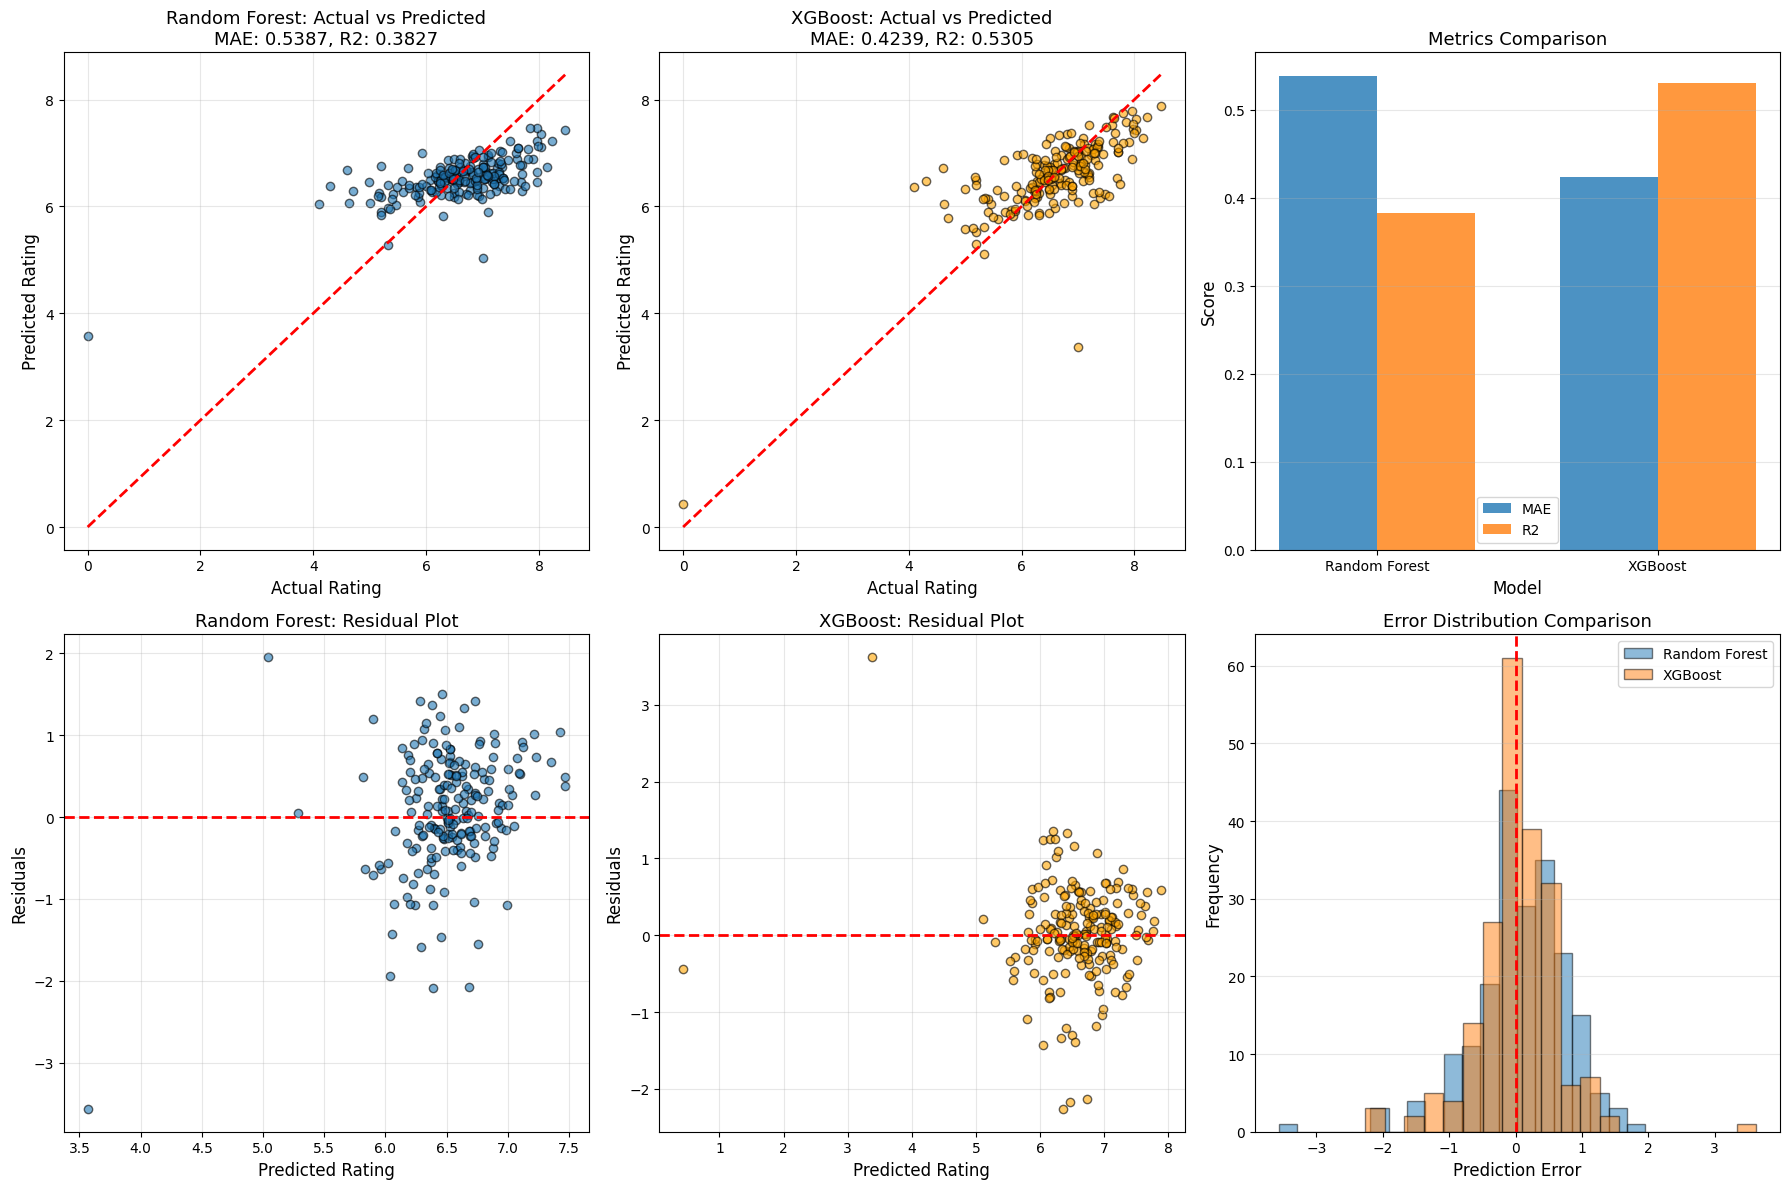

Visualizations saved as 'model_comparison_tuned.png'


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Actual vs Predicted - Random Forest
axes[0, 0].scatter(y_test_np, rf_test_pred, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test_np.min(), y_test_np.max()],
                [y_test_np.min(), y_test_np.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Rating', fontsize=12)
axes[0, 0].set_ylabel('Predicted Rating', fontsize=12)
axes[0, 0].set_title(f'Random Forest: Actual vs Predicted\nMAE: {rf_test_mae:.4f}, R2: {rf_test_r2:.4f}', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted - XGBoost
axes[0, 1].scatter(y_test_np, xgb_test_pred, alpha=0.6, edgecolors='k', color='orange')
axes[0, 1].plot([y_test_np.min(), y_test_np.max()],
                [y_test_np.min(), y_test_np.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Rating', fontsize=12)
axes[0, 1].set_ylabel('Predicted Rating', fontsize=12)
axes[0, 1].set_title(f'XGBoost: Actual vs Predicted\nMAE: {xgb_test_mae:.4f}, R2: {xgb_test_r2:.4f}', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Metrics Comparison
metrics_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Test MAE': [rf_test_mae, xgb_test_mae],
    'Test R2': [rf_test_r2, xgb_test_r2]
})
x = np.arange(len(metrics_df))
width = 0.35
axes[0, 2].bar(x - width/2, metrics_df['Test MAE'], width, label='MAE', alpha=0.8)
axes[0, 2].bar(x + width/2, metrics_df['Test R2'], width, label='R2', alpha=0.8)
axes[0, 2].set_xlabel('Model', fontsize=12)
axes[0, 2].set_ylabel('Score', fontsize=12)
axes[0, 2].set_title('Metrics Comparison', fontsize=13)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(metrics_df['Model'])
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Plot 4: Residuals - Random Forest
rf_residuals = y_test_np - rf_test_pred
axes[1, 0].scatter(rf_test_pred, rf_residuals, alpha=0.6, edgecolors='k')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Rating', fontsize=12)
axes[1, 0].set_ylabel('Residuals', fontsize=12)
axes[1, 0].set_title('Random Forest: Residual Plot', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Residuals - XGBoost
xgb_residuals = y_test_np - xgb_test_pred
axes[1, 1].scatter(xgb_test_pred, xgb_residuals, alpha=0.6, edgecolors='k', color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Rating', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].set_title('XGBoost: Residual Plot', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Error Distribution Comparison
axes[1, 2].hist(rf_residuals, bins=20, alpha=0.5, label='Random Forest', edgecolor='black')
axes[1, 2].hist(xgb_residuals, bins=20, alpha=0.5, label='XGBoost', edgecolor='black')
axes[1, 2].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 2].set_xlabel('Prediction Error', fontsize=12)
axes[1, 2].set_ylabel('Frequency', fontsize=12)
axes[1, 2].set_title('Error Distribution Comparison', fontsize=13)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved as 'model_comparison_tuned.png'")

# Feature Importance

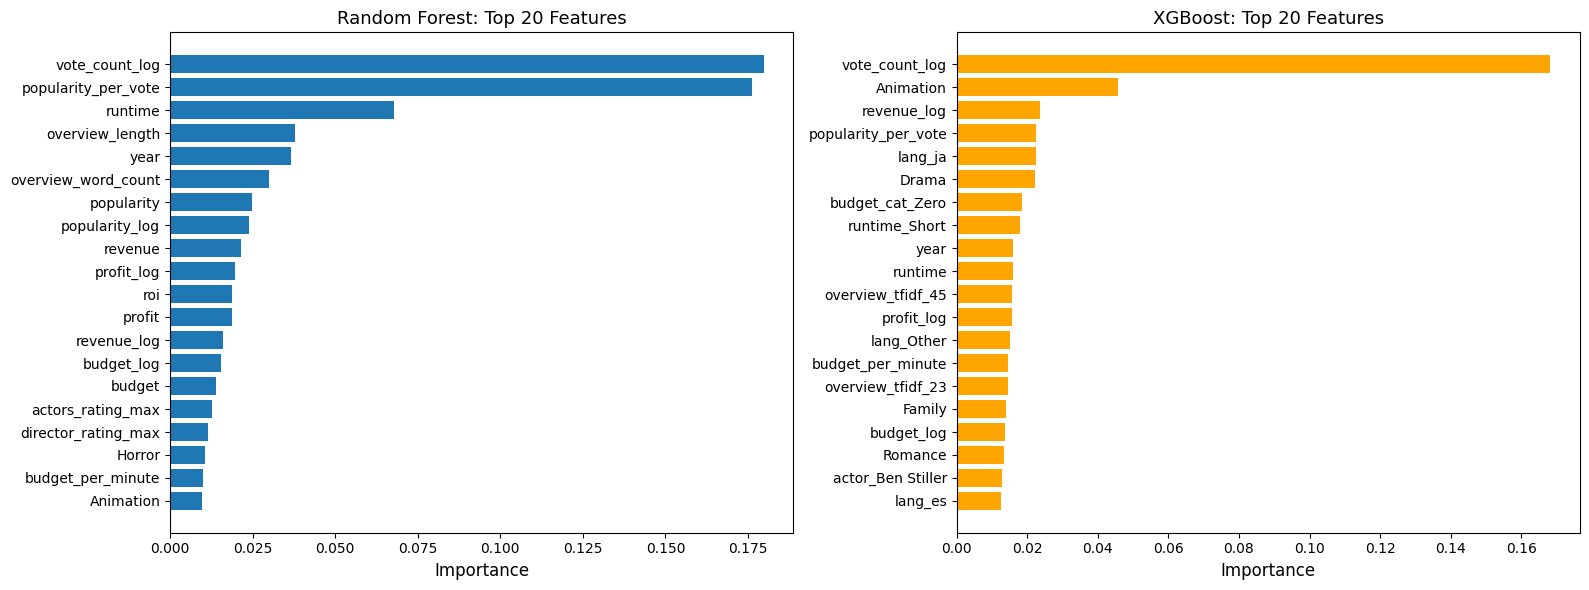

Feature importance saved as 'feature_importance_tuned.png'


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).head(20)

axes[0].barh(range(len(rf_importance)), rf_importance['importance'])
axes[0].set_yticks(range(len(rf_importance)))
axes[0].set_yticklabels(rf_importance['feature'])
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Random Forest: Top 20 Features', fontsize=13)
axes[0].invert_yaxis()

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False).head(20)

axes[1].barh(range(len(xgb_importance)), xgb_importance['importance'], color='orange')
axes[1].set_yticks(range(len(xgb_importance)))
axes[1].set_yticklabels(xgb_importance['feature'])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('XGBoost: Top 20 Features', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature importance saved as 'feature_importance_tuned.png'")

# **Save Best Model**

In [74]:
import pickle

# Save best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save hyperparameters and metadata
best_params = xgb_grid.best_params_ if best_model_name == "XGBoost" else rf_grid.best_params_

model_metadata = {
    'model_type': best_model_name,
    'parameters': best_params,
    'test_mae': best_mae,
    'test_r2': best_r2,
    'train_mae': xgb_train_mae if best_model_name == "XGBoost" else rf_train_mae,
    'feature_names': X_train.columns.tolist(),
    'n_features': X_train.shape[1]
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print(f"Best model saved: {best_model_name}")
print(f"Files created:")
print(f"  - best_model.pkl")
print(f"  - model_metadata.pkl")
print(f"\nModel Performance:")
print(f"  Test MAE: {best_mae:.4f}")
print(f"  Test R2: {best_r2:.4f}")

Best model saved: XGBoost
Files created:
  - best_model.pkl
  - model_metadata.pkl

Model Performance:
  Test MAE: 0.4239
  Test R2: 0.5305


In [79]:
# Cell: Save Everything Needed for Predictions

import pickle



# . Calculate actor and director average ratings
actor_ratings_dict = {}
for idx, row in df.iterrows():
    for actor in row['actors_list']:
        if actor not in actor_ratings_dict:
            actor_ratings_dict[actor] = []
        actor_ratings_dict[actor].append(row['vote_average'])

actor_avg_ratings = {actor: np.mean(ratings) for actor, ratings in actor_ratings_dict.items()}

director_ratings_dict = {}
for idx, row in df.iterrows():
    for director in row['director_list']:
        if director not in director_ratings_dict:
            director_ratings_dict[director] = []
        director_ratings_dict[director].append(row['vote_average'])

director_avg_ratings = {director: np.mean(ratings) for director, ratings in director_ratings_dict.items()}

global_avg_rating = df['vote_average'].mean()

# . Get all unique genres (from the encoded columns)
# Extract genre column names (they were created by MultiLabelBinarizer)
genre_columns = [col for col in df.columns if col not in [
    'tmdb_id', 'title', 'release_date', 'year', 'original_language',
    'runtime', 'budget', 'revenue', 'popularity', 'vote_average', 'vote_count',
    'director', 'top_actors', 'overview', 'success_label', 'success_reason',
    'actors_list', 'director_list', 'release_month', 'release_day_of_week',
    'release_quarter', 'is_summer_release', 'is_holiday_release',
    'actors_rating_mean', 'actors_rating_max', 'actors_rating_min',
    'director_rating_mean', 'director_rating_max', 'director_rating_min',
    'num_actors', 'num_top_actors', 'has_top_director', 'budget_log',
    'revenue_log', 'has_budget', 'profit', 'profit_log', 'roi',
    'is_standard_length', 'popularity_log', 'vote_count_log',
    'overview_length', 'overview_word_count', 'budget_per_minute',
    'popularity_per_vote', 'num_genres'
] and not col.startswith('actor_') and not col.startswith('director_')
  and not col.startswith('lang_') and not col.startswith('budget_cat_')
  and not col.startswith('runtime_') and not col.startswith('pop_')]

all_genres = [col for col in X_train.columns if not any([
    col.startswith('actor_'),
    col.startswith('director_'),
    col.startswith('lang_'),
    col.startswith('budget_cat_'),
    col.startswith('runtime_'),
    col.startswith('pop_'),
    col in ['release_month', 'release_day_of_week', 'release_quarter',
            'is_summer_release', 'is_holiday_release', 'num_genres',
            'actors_rating_mean', 'actors_rating_max', 'actors_rating_min',
            'director_rating_mean', 'director_rating_max', 'director_rating_min',
            'num_actors', 'num_top_actors', 'has_top_director',
            'budget_log', 'revenue_log', 'has_budget', 'profit', 'profit_log', 'roi',
            'is_standard_length', 'popularity_log', 'vote_count_log',
            'overview_length', 'overview_word_count', 'budget_per_minute',
            'popularity_per_vote', 'runtime', 'budget', 'revenue', 'popularity',
            'year', 'vote_count']
])]

print(f"Found {len(all_genres)} genres: {all_genres}")

preprocessing_artifacts = {
    # Feature names and order
    'feature_names': X_train.columns.tolist(),

    # Top actors/directors for multi-hot encoding
    'top_actors': top_actors,
    'top_directors': top_directors,

    # Actor/Director average ratings for target encoding
    'actor_avg_ratings': actor_avg_ratings,
    'director_avg_ratings': director_avg_ratings,
    'global_avg_rating': global_avg_rating,

    # All genres for multi-hot encoding
    'all_genres': all_genres,

    # Model metadata
    'model_type': best_model_name,
    'test_mae': best_mae,
    'test_r2': best_r2,
    'n_features': len(X_train.columns)
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(preprocessing_artifacts, f)

print("\nSuccessfully saved:")
print("  - best_model.pkl")
print("  - preprocessing_artifacts.pkl")
print(f"\nModel: {best_model_name}")
print(f"Features: {len(X_train.columns)}")
print(f"Actors: {len(top_actors)}")
print(f"Directors: {len(top_directors)}")
print(f"Genres: {len(all_genres)}")
print(f"Test MAE: {best_mae:.4f}")
print(f"Test R2: {best_r2:.4f}")

print(f"\nActor ratings calculated: {len(actor_avg_ratings)}")
print(f"Director ratings calculated: {len(director_avg_ratings)}")
print(f"Global average rating: {global_avg_rating:.4f}")

Found 68 genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western', 'overview_tfidf_0', 'overview_tfidf_1', 'overview_tfidf_2', 'overview_tfidf_3', 'overview_tfidf_4', 'overview_tfidf_5', 'overview_tfidf_6', 'overview_tfidf_7', 'overview_tfidf_8', 'overview_tfidf_9', 'overview_tfidf_10', 'overview_tfidf_11', 'overview_tfidf_12', 'overview_tfidf_13', 'overview_tfidf_14', 'overview_tfidf_15', 'overview_tfidf_16', 'overview_tfidf_17', 'overview_tfidf_18', 'overview_tfidf_19', 'overview_tfidf_20', 'overview_tfidf_21', 'overview_tfidf_22', 'overview_tfidf_23', 'overview_tfidf_24', 'overview_tfidf_25', 'overview_tfidf_26', 'overview_tfidf_27', 'overview_tfidf_28', 'overview_tfidf_29', 'overview_tfidf_30', 'overview_tfidf_31', 'overview_tfidf_32', 'overview_tfidf_33', 'overview_tfidf_34', 'overview_tfidf_35', 'overview_tfidf_36', 'overview_tfidf_3